# Setup
Project paths and constants.


In [1]:
import json
import os

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf
from sklearn.metrics import ConfusionMatrixDisplay, classification_report, confusion_matrix
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.applications import EfficientNetB0

PROJECT_ROOT = r"C:\Users\banya\crop-disease-detection-deep-learning"
DATA_DIR = os.path.join(PROJECT_ROOT, "data", "new_plant_diseases_dataset")
TRAIN_DIR = os.path.join(DATA_DIR, "train")
VALID_DIR = os.path.join(DATA_DIR, "valid")
MODELS_DIR = os.path.join(PROJECT_ROOT, "models")
RESULTS_DIR = os.path.join(PROJECT_ROOT, "results")
FIGURES_DIR = os.path.join(RESULTS_DIR, "figures")
MODEL_PATH = os.path.join(MODELS_DIR, "crop_disease_efficientnetb0_2.keras")
METRICS_PATH = os.path.join(RESULTS_DIR, "efficientnetb0_metrics.json")
CLASSIFICATION_REPORT_PATH = os.path.join(RESULTS_DIR, "efficientnetb0_classification_report.csv")
ACCURACY_FIG_PATH = os.path.join(FIGURES_DIR, "efficientnetb0_accuracy_curve.png")
LOSS_FIG_PATH = os.path.join(FIGURES_DIR, "efficientnetb0_loss_curve.png")
CONFUSION_MATRIX_PATH = os.path.join(FIGURES_DIR, "efficientnetb0_confusion_matrix.png")
SAMPLE_PREDICTIONS_PATH = os.path.join(FIGURES_DIR, "efficientnetb0_sample_predictions.png")
GRADCAM_PATH = os.path.join(FIGURES_DIR, "efficientnetb0_gradcam_examples.png")
MODEL_COMPARISON_JSON = os.path.join(RESULTS_DIR, "model_comparison.json")
MODEL_COMPARISON_CSV = os.path.join(RESULTS_DIR, "model_comparison_table.csv")
MODEL_COMPARISON_ACC_FIG = os.path.join(FIGURES_DIR, "model_comparison_accuracy.png")
MODEL_COMPARISON_LOSS_FIG = os.path.join(FIGURES_DIR, "model_comparison_loss.png")

IMG_SIZE = (224, 224)
BATCH_SIZE = 32
SEED = 30

os.makedirs(MODELS_DIR, exist_ok=True)
os.makedirs(RESULTS_DIR, exist_ok=True)
os.makedirs(FIGURES_DIR, exist_ok=True)

keras.utils.set_random_seed(SEED)
tf.random.set_seed(SEED)


# Load Dataset
Load train and validation splits.


In [2]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=SEED,
)

valid_ds = tf.keras.utils.image_dataset_from_directory(
    VALID_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False,
)

class_names = train_ds.class_names
num_classes = len(class_names)
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.prefetch(AUTOTUNE)
valid_ds = valid_ds.prefetch(AUTOTUNE)

print(f"Classes: {num_classes}")
print(f"Train batches: {tf.data.experimental.cardinality(train_ds).numpy()}")
print(f"Valid batches: {tf.data.experimental.cardinality(valid_ds).numpy()}")


Found 70295 files belonging to 38 classes.
Found 17572 files belonging to 38 classes.
Classes: 38
Train batches: 2197
Valid batches: 550


# Build EfficientNetB0 Model
Freeze the ImageNet base and add augmentation in the model.


In [3]:
base_model = EfficientNetB0(
    input_shape=IMG_SIZE + (3,),
    include_top=False,
    weights="imagenet",
)
base_model.trainable = False

efficientnet_model = keras.Sequential(
    [
        layers.Input(shape=IMG_SIZE + (3,)),
        layers.RandomFlip("horizontal"),
        layers.RandomRotation(0.1),
        layers.RandomZoom(0.1),
        base_model,
        layers.GlobalAveragePooling2D(),
        layers.Dropout(0.3),
        layers.Dense(num_classes, activation="softmax"),
    ],
    name="efficientnetb0_classifier",
)

efficientnet_model.compile(
    optimizer=keras.optimizers.Adam(),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

efficientnet_model.summary()


Model: "efficientnetb0_classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ random_flip (RandomFlip)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation                 │ (None, 224, 224, 3)    │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_zoom (RandomZoom)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 38)             │        48,678 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,098,249 (15.63 MB)

 Trainable params: 48,678 (190.15 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

# Training


In [7]:
RUN_TRAINING = True
EPOCHS = 10

if RUN_TRAINING:
    history = efficientnet_model.fit(
        train_ds,
        validation_data=valid_ds,
        epochs=EPOCHS,
        verbose=1,
    )
    efficientnet_model.save(MODEL_PATH)
    print(f"Saved model to {MODEL_PATH}")
else:
    print("Training skipped.")


Epoch 1/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 565s 257ms/step - accuracy: 0.8964 - loss: 0.4338 - val_accuracy: 0.9388 - val_loss: 0.2150
Epoch 2/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 582s 265ms/step - accuracy: 0.9369 - loss: 0.2164 - val_accuracy: 0.9532 - val_loss: 0.1589
Epoch 3/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 606s 276ms/step - accuracy: 0.9459 - loss: 0.1779 - val_accuracy: 0.9578 - val_loss: 0.1388
Epoch 4/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 606s 276ms/step - accuracy: 0.9505 - loss: 0.1584 - val_accuracy: 0.9629 - val_loss: 0.1221
Epoch 5/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 606s 276ms/step - accuracy: 0.9532 - loss: 0.1450 - val_accuracy: 0.9626 - val_loss: 0.1166
Epoch 6/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 645s 294ms/step - accuracy: 0.9548 - loss: 0.1393 - val_accuracy: 0.9660 - val_loss: 0.1051
Epoch 7/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 615s 280ms/step - accuracy: 0.9544 - loss: 0.1385 - val_accuracy: 0.9676 - val_loss: 0.1008
Epoch 8/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 608s 277ms/step - ac

# Load Saved Model
Use the saved `.keras` model for evaluation.


In [8]:
if not os.path.exists(MODEL_PATH):
    raise FileNotFoundError(MODEL_PATH)

efficientnet_model = keras.models.load_model(MODEL_PATH)
print(f"Loaded model from {MODEL_PATH}")


Loaded model from C:\Users\banya\crop-disease-detection-deep-learning\models\crop_disease_efficientnetb0_2.keras


# Evaluate
Evaluate on `valid/`.


In [9]:
efficientnet_val_loss, efficientnet_val_accuracy = efficientnet_model.evaluate(valid_ds, verbose=1)

print(f"Validation accuracy: {efficientnet_val_accuracy:.6f}")
print(f"Validation loss: {efficientnet_val_loss:.6f}")


550/550 ━━━━━━━━━━━━━━━━━━━━ 116s 207ms/step - accuracy: 0.9702 - loss: 0.0925
Validation accuracy: 0.970237
Validation loss: 0.092496


# Accuracy/Loss Graph
Plot accuracy and loss 


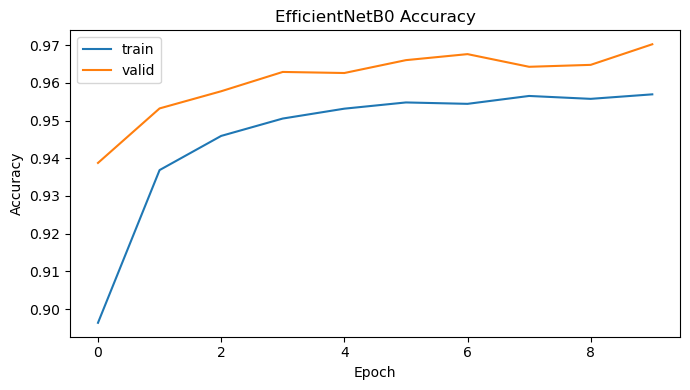

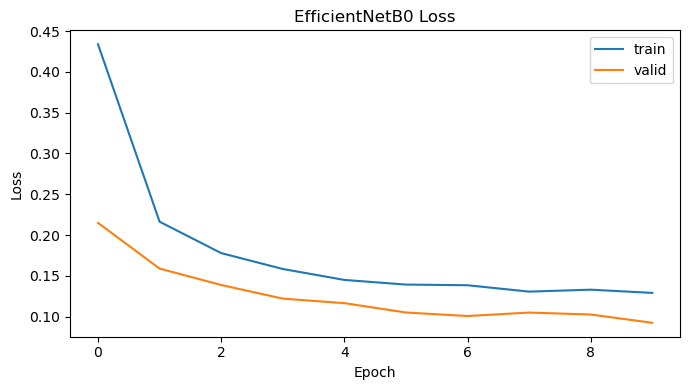

In [ ]:
if "history" in globals():
    history_data = history.history

    plt.figure(figsize=(7, 4))
    plt.plot(history_data["accuracy"], label="train")
    plt.plot(history_data["val_accuracy"], label="valid")
    plt.title("EfficientNetB0 Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.tight_layout()
    plt.savefig(ACCURACY_FIG_PATH, dpi=200)
    plt.show()

    plt.figure(figsize=(7, 4))
    plt.plot(history_data["loss"], label="train")
    plt.plot(history_data["val_loss"], label="valid")
    plt.title("EfficientNetB0 Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.tight_layout()
    plt.savefig(LOSS_FIG_PATH, dpi=200)
    plt.show()
else:
    print("there is no training")
